In [60]:
import numpy as np
import matplotlib.pyplot as plt

In [61]:
x0=2.8
v0=0
m=1
T=100
dx=1e-3
b = [0.5, 5]

In [62]:
def phi(x, l1=1, l2=1/np.sqrt(8)):
    return -np.exp(-x**2/l1**2)-8*np.exp(-(x-2)**2/l2**2)

In [63]:
def acceleration(x, mass=m, deltax=dx):
    return -1/mass * (phi(x + deltax) - phi(x - deltax)) / (2*deltax)

In [64]:
def resistance_factor(v, b=0):
    return -b*v

In [65]:
def energy(x, v, mass=m):
    return 0.5*mass*v**2+phi(x)

In [66]:
def adaptive_integrate(method, d, x0, v0, T, dt0=1e-4, tol=1e-5, c=0.9, m=1.0, dx=1e-3, b=0):
    t = 0.0
    dt = dt0
    step_count = 0
    
    t_arr = np.array([t])
    dt_arr = np.array([dt])
    x_arr = np.array([x0])
    v_arr = np.array([v0])
    E_arr = np.array([energy(x0, v0, m)])
    
    x, v = x0, v0

    while t < T:
        if t + 2*dt > T:
            dt = (T-t)/2

        x_big, v_big = method(x, v, 2*dt, m, dx, b)

        x_temp, v_temp = method(x, v, dt, m, dx, b)
        x_small, v_small = method(x_temp, v_temp, dt, m, dx, b)

        eps_x = np.abs(x_small - x_big) / (2**d - 1)
        eps_v = np.abs(v_small - v_big) / (2**d - 1)
        
        eps = max(eps_x, eps_v)

        if eps <= tol:
            t += 2 * dt
            x, v = x_small, v_small
            
            t_arr = np.append(t_arr, t)
            dt_arr = np.append(dt_arr, dt)
            x_arr = np.append(x_arr, x)
            v_arr = np.append(v_arr, v)
            E_arr = np.append(E_arr, energy(x, v))          
            
            step_count += 1 

        if eps == 0:
            dt *= 2 
        else:
            dt = c * dt * (tol / eps)**(1 / (d + 1))

    return t_arr, dt_arr, x_arr, v_arr, E_arr, step_count

In [67]:
def euler(xn, vn, dt, mass=m, deltax=dx, b=0):
    an = acceleration(xn, mass, deltax) + resistance_factor(vn, b)
    return (xn+vn*dt), (vn+an*dt)

In [68]:
def verlet(xn, vn, dt, mass=m, deltax=dx, b=0):
    an=acceleration(xn, mass, deltax)
    x_new=xn+vn*dt+0.5*an*(dt**2)
    an1 = acceleration(x_new, mass, deltax)
    v_new = vn + 0.5*(an + an1)*dt
    return x_new, v_new

In [69]:
def rk4(xn, vn, dt, mass=m, deltax=dx, b=0):
    def f(x, v):
        a = acceleration(x, mass, deltax) + resistance_factor(v, b)
        return np.array([v, a])
    
    k1 = f(xn, vn)
    k2 = f(xn + 0.5*dt*k1[0], vn + 0.5*dt*k1[1])
    k3 = f(xn + 0.5*dt*k2[0], vn + 0.5*dt*k2[1])
    k4 = f(xn + dt*k3[0], vn + dt*k3[1])
    
    x_new = xn + (dt/6.0)*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    v_new = vn + (dt/6.0)*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    return x_new, v_new


In [70]:
results = {}

In [71]:
te, dte, xe, ve, Ee, steps_e = adaptive_integrate(euler, d=1, x0=x0, v0=v0, T=T, dt0=1e-4, tol=1e-7)
results['Euler'] = (te, dte, xe, ve, Ee, steps_e)

In [72]:
tv, dtv, xv, vv, Ev, steps_v = adaptive_integrate(verlet, d=2, x0=x0, v0=v0, T=T, dt0=1e-3, tol=1e-7)
results['Verlet'] = (tv, dtv, xv, vv, Ev, steps_v)

In [73]:
tr, dtr, xr, vr, Er, steps_rk = adaptive_integrate(rk4, d=4, x0=x0, v0=v0, T=T, dt0=1e-2, tol=1e-7)
results['RK4'] = (tr, dtr, xr, vr, Er, steps_rk)

In [74]:
for method, (t, dt, x, v, E, steps) in results.items():
    print(f"{method}: wykonane kroki = {steps}, T = {t[-1]:.3f}")
    print(f" dt: min={dt.min():.2e}, max={dt.max():.2e},"
          f" last={dt[-1]:.2e}")
    print("----------------------------------------------------------------------------")

Euler: wykonane kroki = 313174, T = 100.000
 dt: min=1.26e-05, max=9.81e-04, last=5.53e-04
----------------------------------------------------------------------------
Verlet: wykonane kroki = 16492, T = 100.000
 dt: min=3.51e-04, max=1.75e-02, last=6.38e-03
----------------------------------------------------------------------------
RK4: wykonane kroki = 1416, T = 100.000
 dt: min=4.76e-03, max=1.81e-01, last=6.00e-02
----------------------------------------------------------------------------


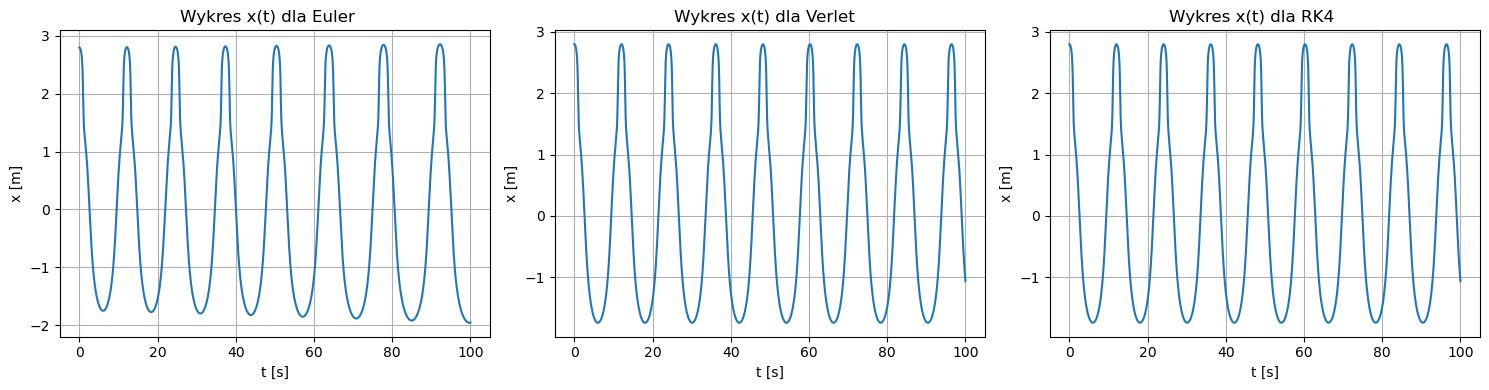

In [75]:
i = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(t, x)
    axes[i].set_title("Wykres x(t) dla {0:8s}".format(method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("x [m]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

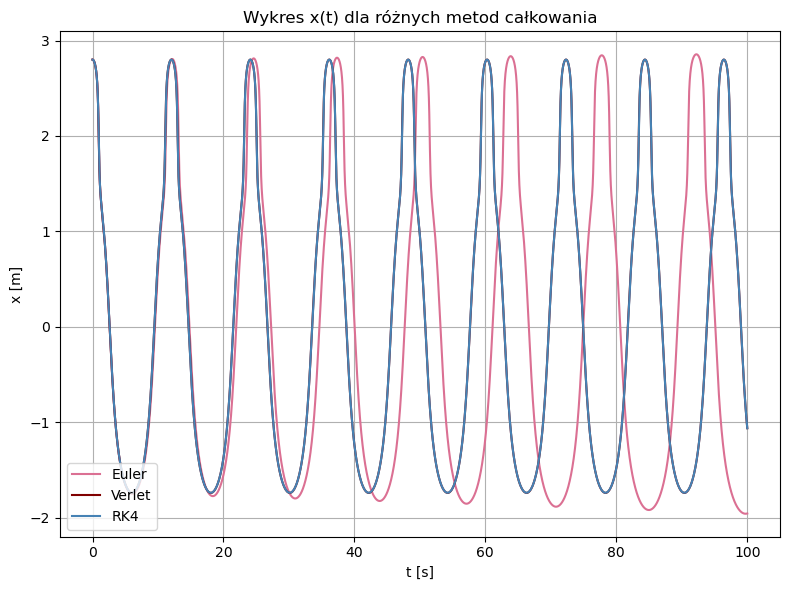

In [76]:
colors = ['palevioletred', 'maroon', 'steelblue']

plt.figure(figsize=(8, 6))
for method, (t, dt, x, v, E, steps) in results.items():
    plt.plot(t, x, label=method, color=colors[i]) 
    i+=1
i=0

plt.title("Wykres x(t) dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("x [m]")
plt.grid(True)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

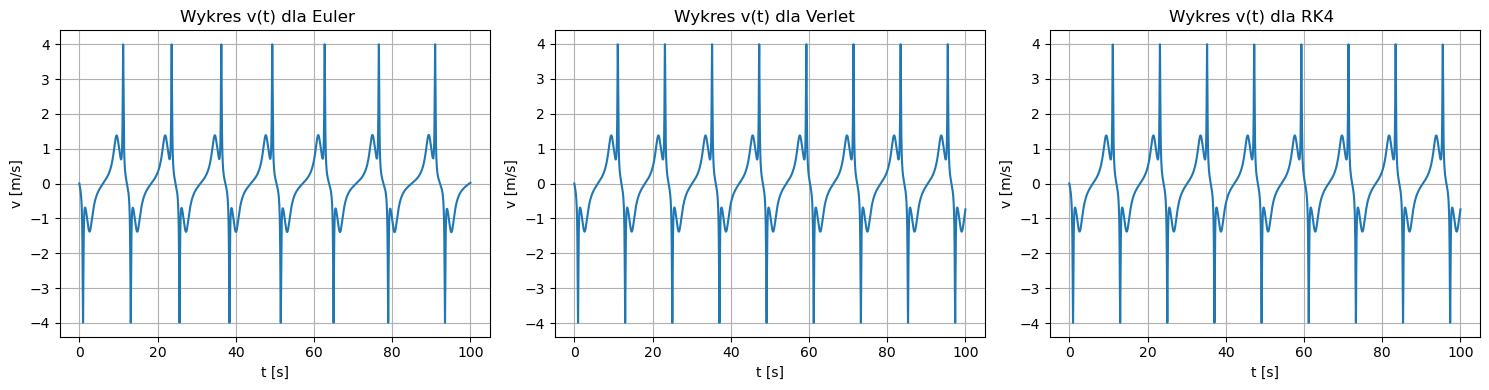

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(t, v)
    axes[i].set_title("Wykres v(t) dla {0:8s}".format(method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

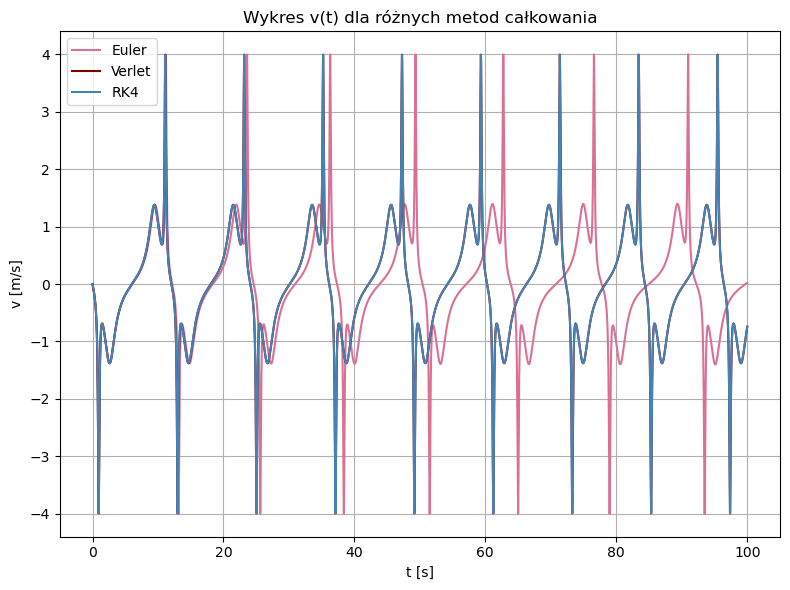

In [78]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results.items():
    plt.plot(t, v, label=method, color=colors[i]) 
    i+=1
i=0

plt.title("Wykres v(t) dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

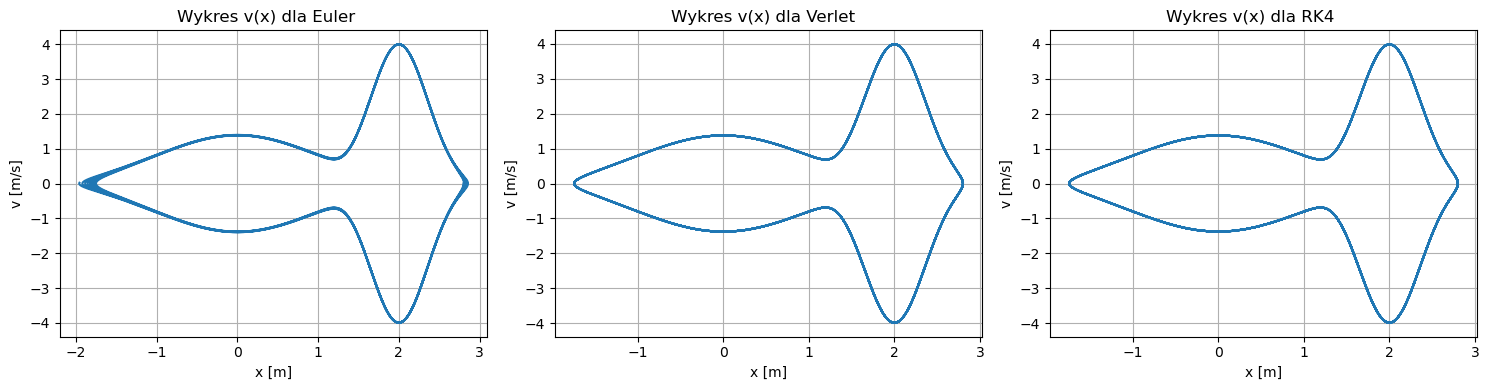

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(x, v)
    axes[i].set_title("Wykres v(x) dla {0:8s}".format(method))
    axes[i].set_xlabel("x [m]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

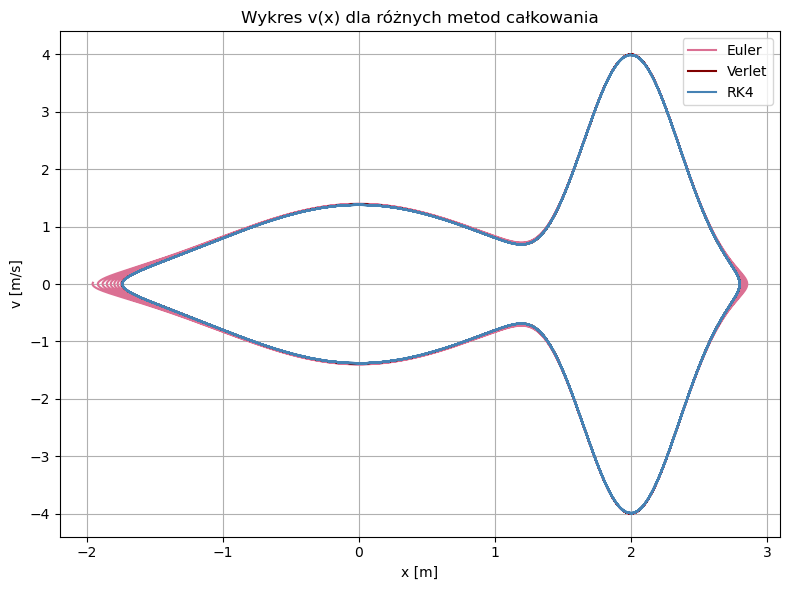

In [80]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results.items():
    plt.plot(x, v, label=method, color=colors[i]) 
    i+=1
i=0

plt.title("Wykres v(x) dla różnych metod całkowania")
plt.xlabel("x [m]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

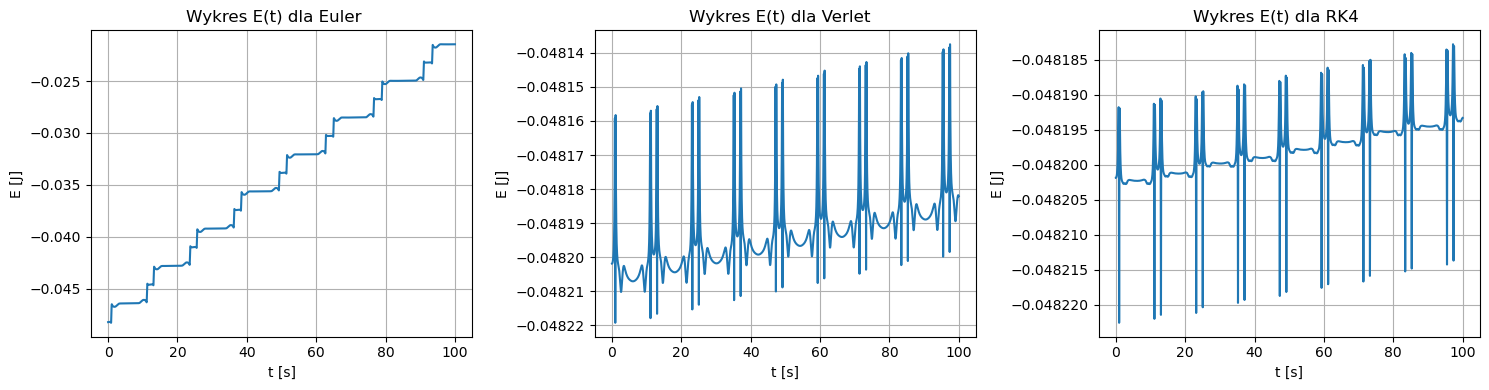

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(t, E)
    axes[i].set_title("Wykres E(t) dla {0:8s}".format(method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("E [J]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

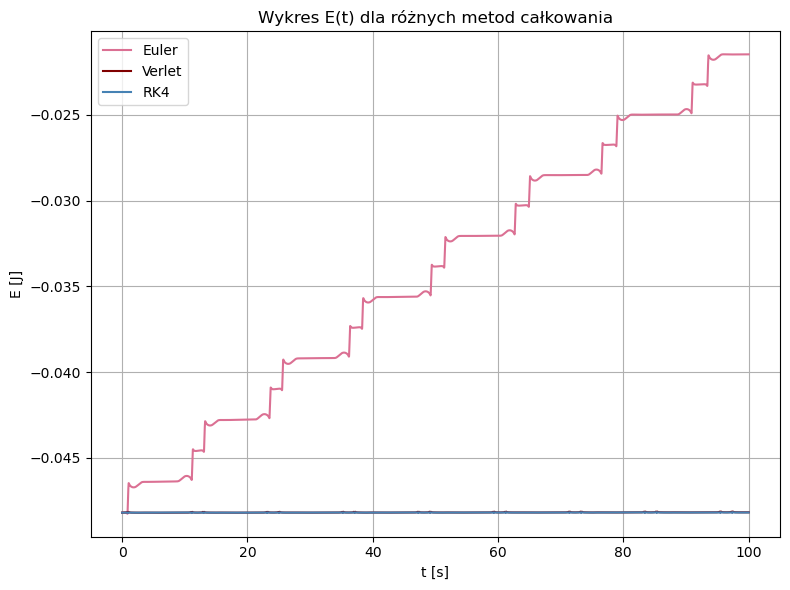

In [82]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results.items():
    plt.plot(t, E, label=method, color=colors[i]) 
    i+=1
i=0

plt.title("Wykres E(t) dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("E [J]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
#zadanie 3
results_resistance1 = {}
results_resistance2 = {}

In [84]:
ter1, dter1, xer1, ver1, Eer1, steps_er1 = adaptive_integrate(euler, d=1, x0=x0, v0=v0, T=T, dt0=1e-4, tol=1e-7,  b=b[0])
results_resistance1['Euler'] = (ter1, dter1, xer1, ver1, Eer1, steps_er1)

In [85]:
trr1, dtrr1, xrr1, vrr1, Err1, steps_rkr1 = adaptive_integrate(rk4, d=4, x0=x0, v0=v0, T=T, dt0=1e-2, tol=1e-7, b=b[0])
results_resistance1['RK4'] = (trr1, dtrr1, xrr1, vrr1, Err1, steps_rkr1)

In [86]:
for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    print(f"{method} z oporem {b[0]:.3f}: wykonane kroki = {steps}, T = {t[-1]:.3f}")
    print(f" dt: min={dt.min():.2e}, max={dt.max():.2e},"
          f" last={dt[-1]:.2e}")
    print("----------------------------------------------------------------------------")

Euler z oporem 0.500: wykonane kroki = 238710, T = 100.000
 dt: min=1.30e-05, max=9.27e-03, last=7.97e-03
----------------------------------------------------------------------------
RK4 z oporem 0.500: wykonane kroki = 1685, T = 100.000
 dt: min=5.01e-03, max=4.08e-01, last=2.43e-02
----------------------------------------------------------------------------


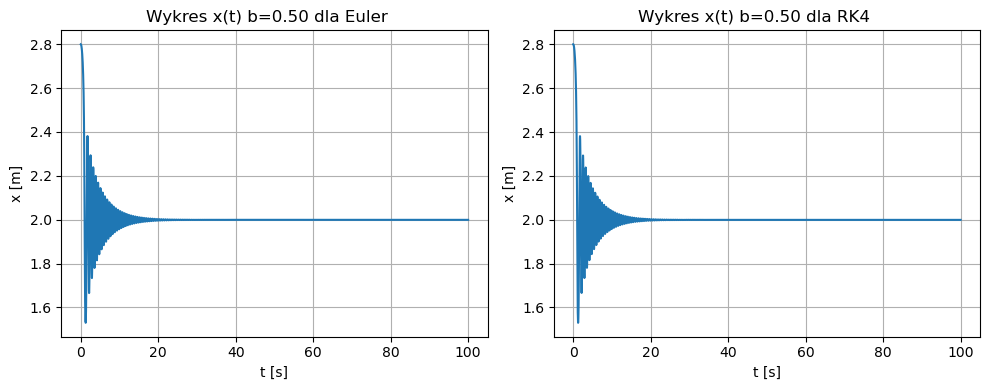

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    axes[i].plot(t, x)
    axes[i].set_title("Wykres x(t) b={0:4.2f} dla {1:8s}".format(b[0], method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("x [m]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

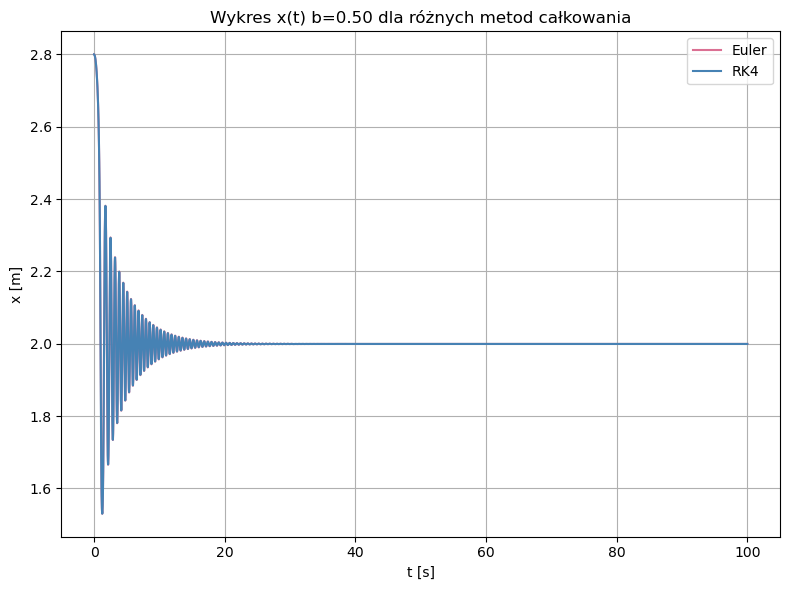

In [88]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    plt.plot(t, x, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres x(t) b=0.50 dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("x [m]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

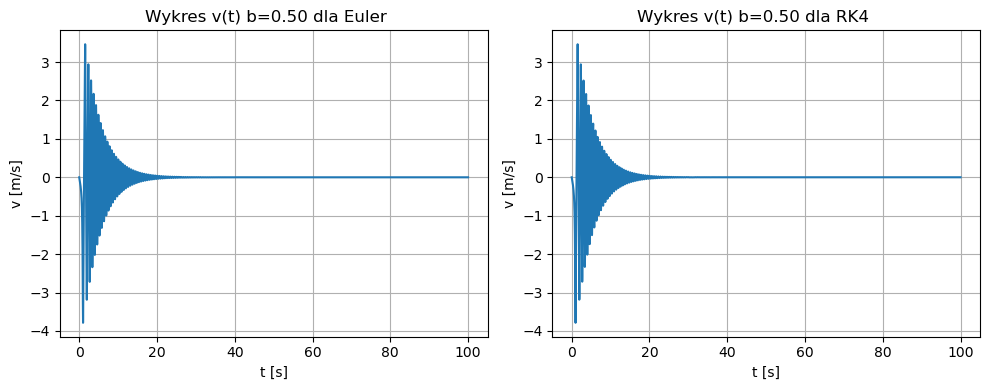

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    axes[i].plot(t, v)
    axes[i].set_title("Wykres v(t) b={0:4.2f} dla {1:8s}".format(b[0], method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

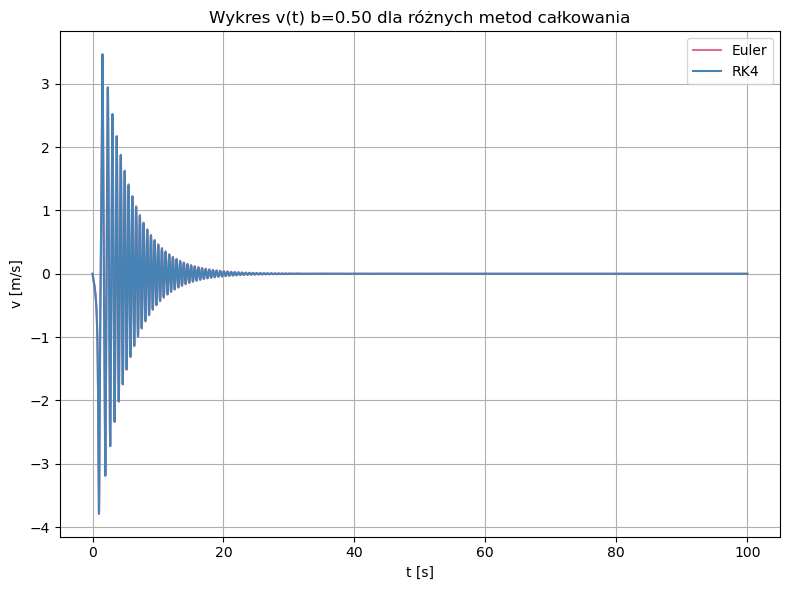

In [90]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    plt.plot(t, v, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres v(t) b=0.50 dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

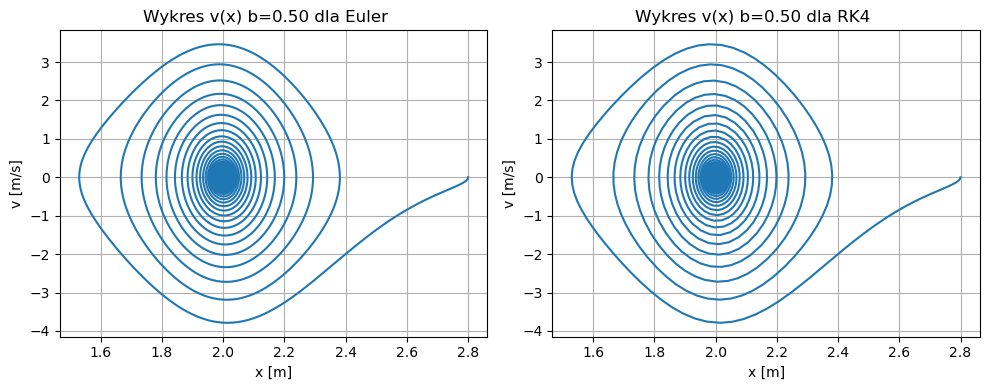

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    axes[i].plot(x, v)
    axes[i].set_title("Wykres v(x) b={0:4.2f} dla {1:8s}".format(b[0], method))
    axes[i].set_xlabel("x [m]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

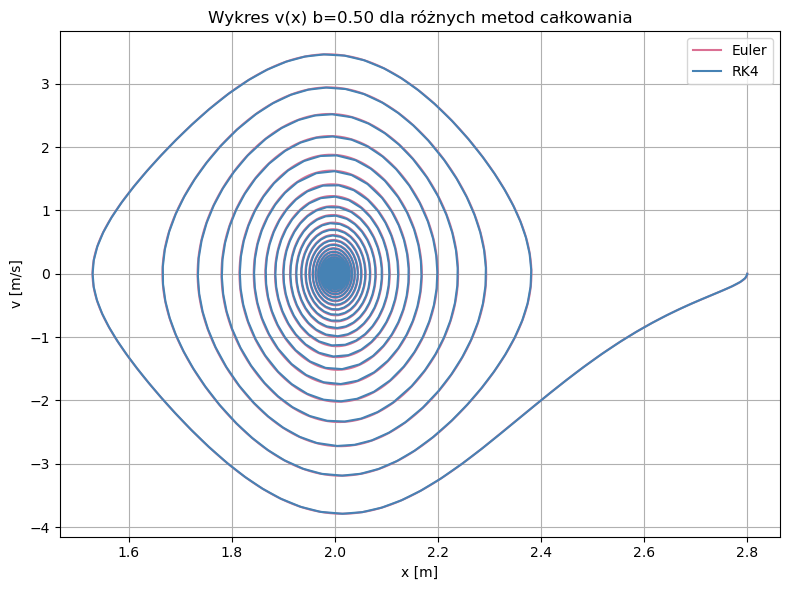

In [92]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    plt.plot(x, v, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres v(x) b=0.50 dla różnych metod całkowania")
plt.xlabel("x [m]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

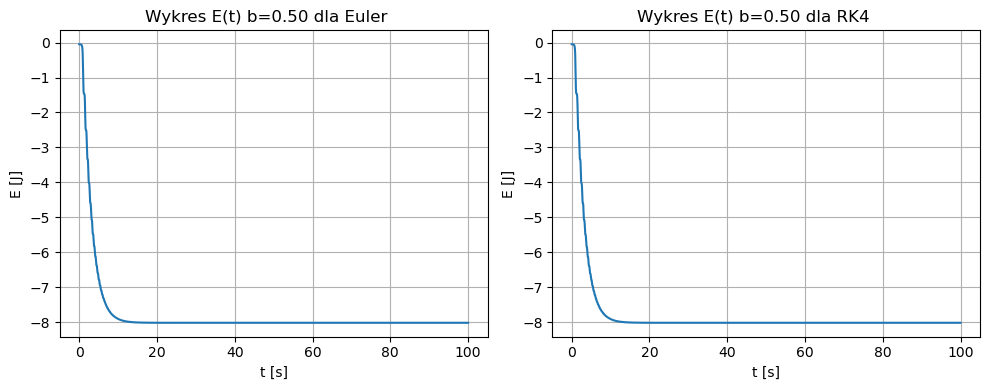

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    axes[i].plot(t, E)
    axes[i].set_title("Wykres E(t) b={0:4.2f} dla {1:8s}".format(b[0], method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("E [J]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

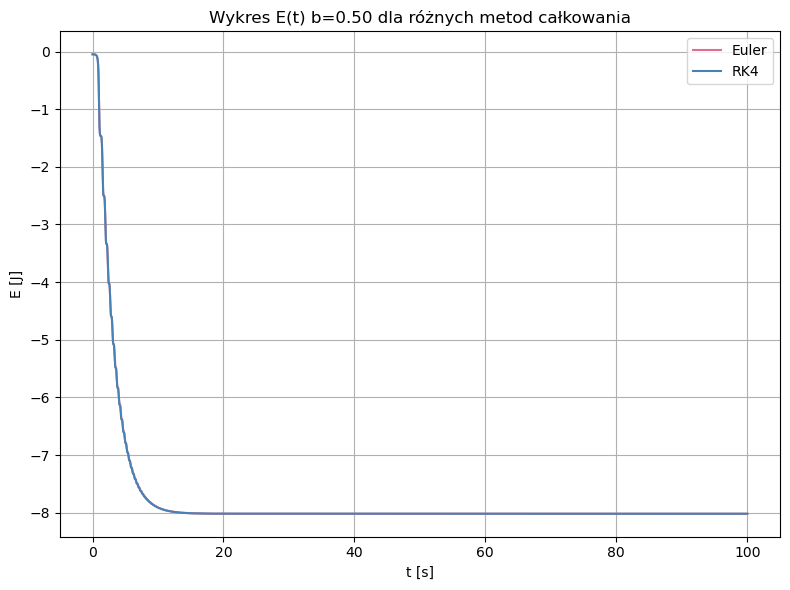

In [94]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance1.items():
    plt.plot(t, E, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres E(t) b=0.50 dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("E [J]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
ter2, dter2, xer2, ver2, Eer2, steps_er2 = adaptive_integrate(euler, d=1, x0=x0, v0=v0, T=T, dt0=1e-4, tol=1e-7, b=b[1])
results_resistance2['Euler'] = (ter2, dter2, xer2, ver2, Eer2, steps_er2)

In [96]:
trr2, dtrr2, xrr2, vrr2, Err2, steps_rkr2 = adaptive_integrate(rk4, d=4, x0=x0, v0=v0, T=T, dt0=1e-2, tol=1e-7, b=b[1])
results_resistance2['RK4'] = (trr2, dtrr2, xrr2, vrr2, Err2, steps_rkr2)

In [97]:
for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    print(f"{method} z oporem {b[1]:.3f}: wykonane kroki = {steps}, T = {t[-1]:.3f}")
    print(f" dt: min={dt.min():.2e}, max={dt.max():.2e},"
          f" last={dt[-1]:.2e}")
    print("----------------------------------------------------------------------------")

Euler z oporem 5.000: wykonane kroki = 26503, T = 100.000
 dt: min=1.76e-05, max=5.73e-02, last=2.52e-02
----------------------------------------------------------------------------
RK4 z oporem 5.000: wykonane kroki = 410, T = 100.000
 dt: min=5.54e-03, max=4.87e-01, last=2.33e-01
----------------------------------------------------------------------------


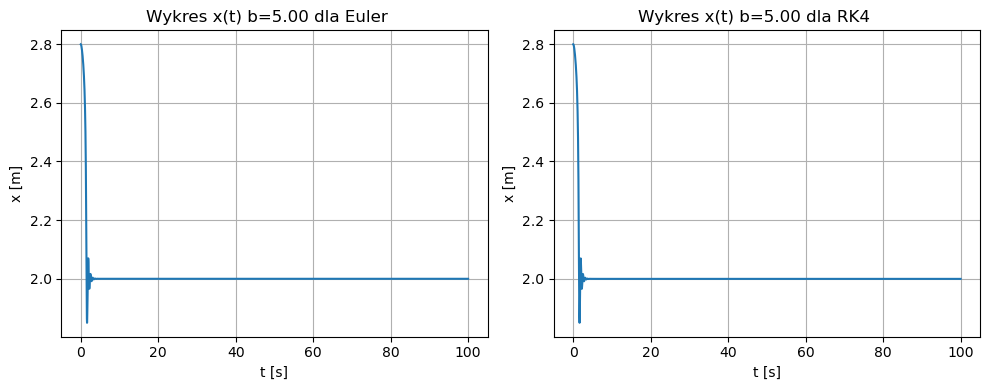

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    axes[i].plot(t, x)
    axes[i].set_title("Wykres x(t) b={0:4.2f} dla {1:8s}".format(b[1], method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("x [m]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

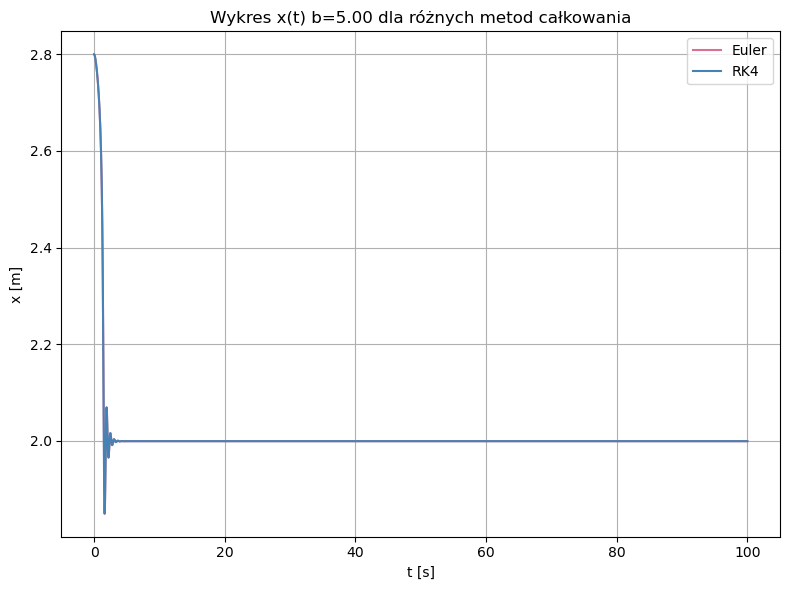

In [99]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    plt.plot(t, x, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres x(t) b=5.00 dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("x [m]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

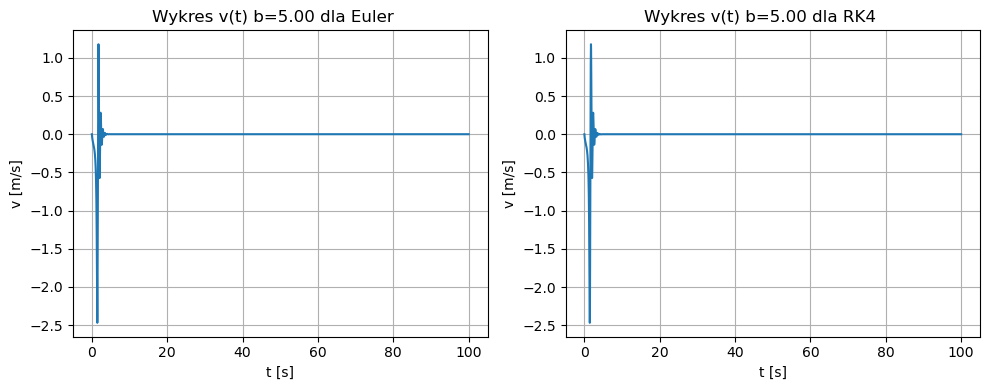

In [100]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    axes[i].plot(t, v)
    axes[i].set_title("Wykres v(t) b={0:4.2f} dla {1:8s}".format(b[1], method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

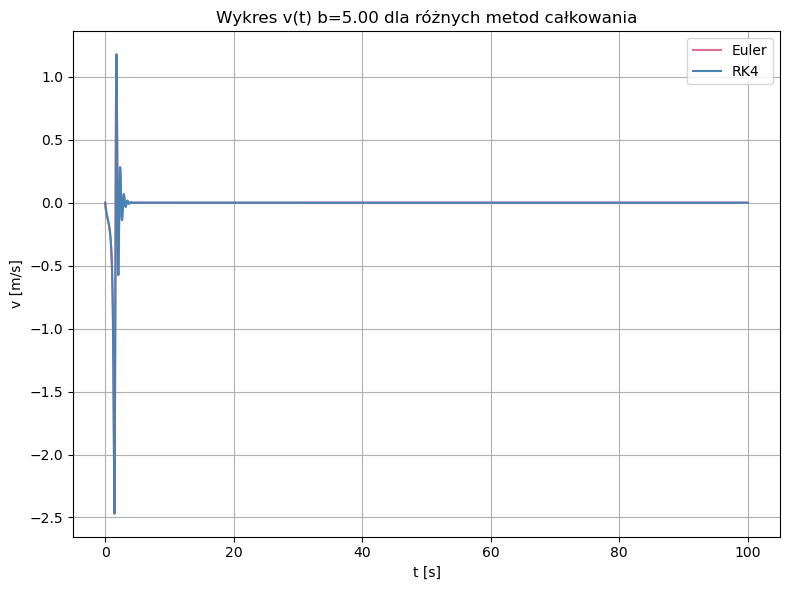

In [101]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    plt.plot(t, v, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres v(t) b=5.00 dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

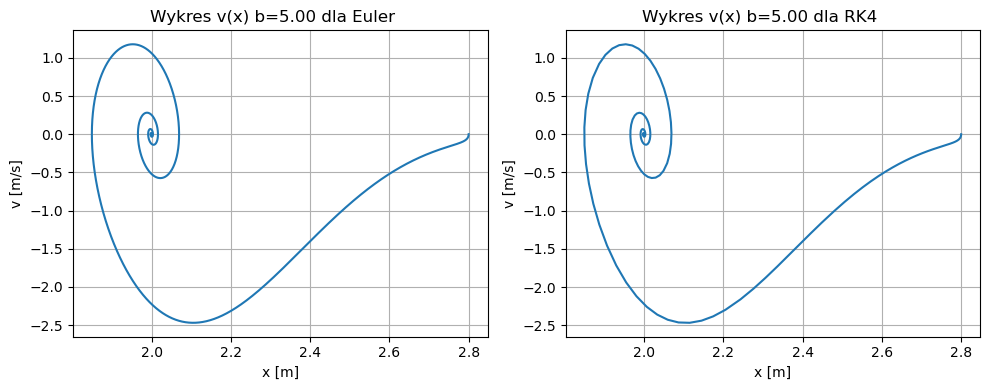

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    axes[i].plot(x, v)
    axes[i].set_title("Wykres v(x) b={0:4.2f} dla {1:8s}".format(b[1], method))
    axes[i].set_xlabel("x [m]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

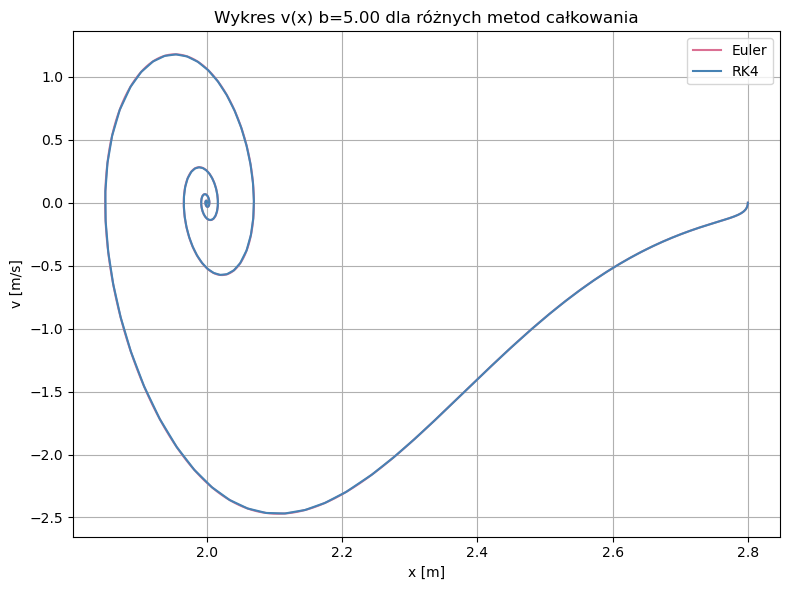

In [103]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    plt.plot(x, v, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres v(x) b=5.00 dla różnych metod całkowania")
plt.xlabel("x [m]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

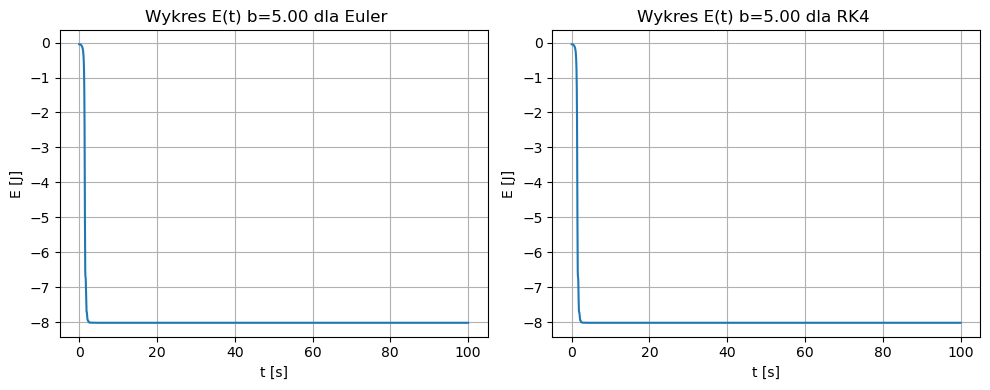

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    axes[i].plot(t, E)
    axes[i].set_title("Wykres E(t) b={0:4.2f} dla {1:8s}".format(b[1], method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("E [J]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

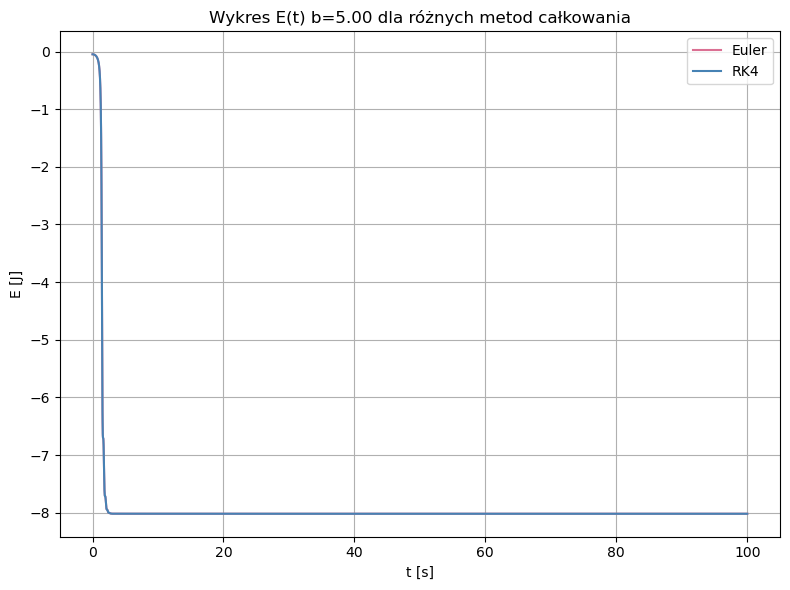

In [105]:
plt.figure(figsize=(8, 6))

for method, (t, dt, x, v, E, steps) in results_resistance2.items():
    plt.plot(t, E, label=method, color=colors[i]) 
    i+=2
i=0

plt.title("Wykres E(t) b=5.00 dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("E [J]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()